<a href="https://colab.research.google.com/github/e23281-lgtm/Statistical-Learning-e23281/blob/main/Copy_of_GPR_LR_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [ ]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [ ]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


In [ ]:
!pip install gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 6.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
import gpytorch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load and preprocess the data
# Assuming df2 is already loaded from your kaggle path
# Columns: X1 to X8 are features; Y1 (Heating Load) and Y2 (Cooling Load) are targets
X = df2[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']].values
Y = df2[['Y1', 'Y2']].values

# Split data into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scale features and targets for optimal GP convergence
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_test_scaled = scaler_Y.transform(Y_test)

# Convert to PyTorch Tensors for GPyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# 2. Define Multitask GP Model
class MultitaskGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(MultitaskGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.MultitaskMean(
            gpytorch.means.ConstantMean(), num_tasks=2
        )
        self.covar_module = gpytorch.kernels.MultitaskKernel(
            gpytorch.kernels.RBFKernel(), num_tasks=2, rank=1
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)

likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=2)
model = MultitaskGPModel(X_train_tensor, Y_train_tensor, likelihood)

# 3. Train the Model
model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

training_iterations = 100
for i in range(training_iterations):
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = -mll(output, Y_train_tensor)
    loss.backward()
    optimizer.step()

# 4. Predict and Evaluate
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    predictions = likelihood(model(X_test_tensor))
    mean_scaled = predictions.mean.numpy()

# Inverse transform predictions back to original scale (kWh/m²)
mean_original = scaler_Y.inverse_transform(mean_scaled)

# Calculate RMSE for both targets
rmse_heating = np.sqrt(np.mean((Y_test[:, 0] - mean_original[:, 0]) ** 2))
rmse_cooling = np.sqrt(np.mean((Y_test[:, 1] - mean_original[:, 1]) ** 2))

print(f"Test RMSE - Heating Load: {rmse_heating:.4f}")
print(f"Test RMSE - Cooling Load: {rmse_cooling:.4f}")

Test RMSE - Heating Load: 0.4786
Test RMSE - Cooling Load: 1.4134


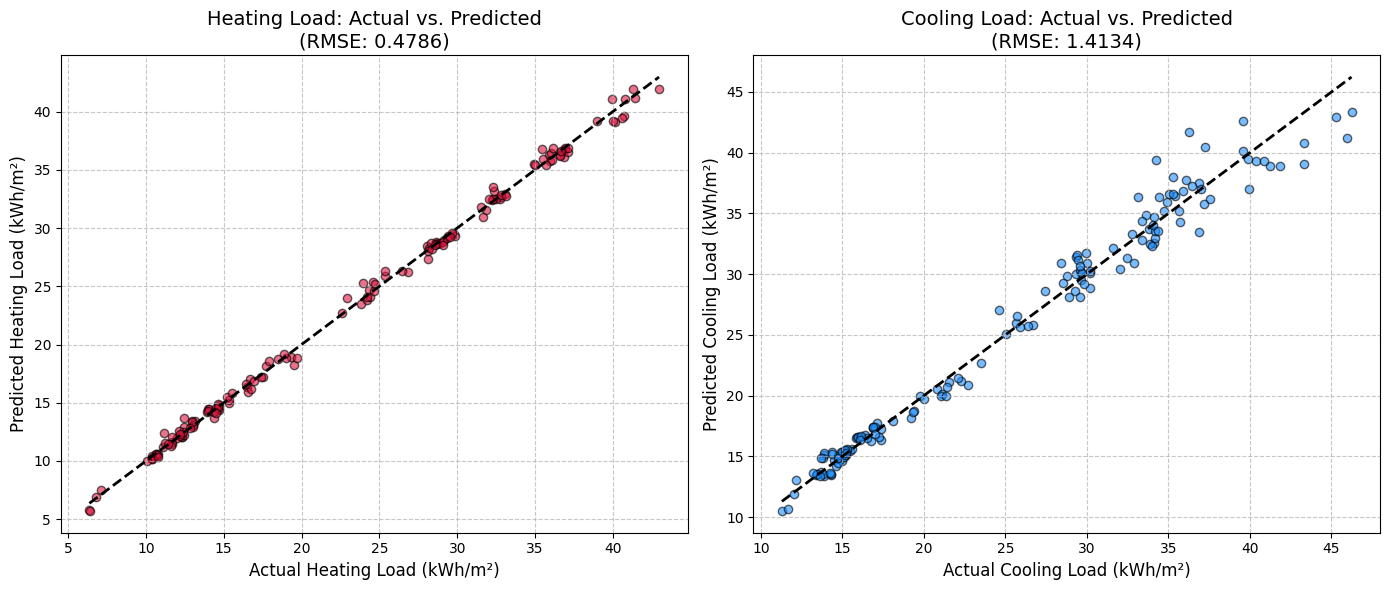

In [ ]:
import matplotlib.pyplot as plt

# Create a side-by-side subplot for Heating and Cooling loads
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Heating Load Plot
ax1.scatter(Y_test[:, 0], mean_original[:, 0], color='crimson', alpha=0.6, edgecolors='k')
ax1.plot([Y_test[:, 0].min(), Y_test[:, 0].max()], [Y_test[:, 0].min(), Y_test[:, 0].max()], 'k--', lw=2)
ax1.set_xlabel('Actual Heating Load (kWh/m²)', fontsize=12)
ax1.set_ylabel('Predicted Heating Load (kWh/m²)', fontsize=12)
ax1.set_title(f'Heating Load: Actual vs. Predicted\n(RMSE: {rmse_heating:.4f})', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Cooling Load Plot
ax2.scatter(Y_test[:, 1], mean_original[:, 1], color='dodgerblue', alpha=0.6, edgecolors='k')
ax2.plot([Y_test[:, 1].min(), Y_test[:, 1].max()], [Y_test[:, 1].min(), Y_test[:, 1].max()], 'k--', lw=2)
ax2.set_xlabel('Actual Cooling Load (kWh/m²)', fontsize=12)
ax2.set_ylabel('Predicted Cooling Load (kWh/m²)', fontsize=12)
ax2.set_title(f'Cooling Load: Actual vs. Predicted\n(RMSE: {rmse_cooling:.4f})', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#1. High Target Correlation Justifies the Setup
 High Target Correlation Justifies the SetupHeating load ($Y_1$) and cooling load ($Y_2$) are strongly correlated because they both stem from the same structural characteristics of the building (e.g., overall thermal transmittance, surface area, and glazing distribution). A building that easily loses heat in the winter (high heating load) often requires significant cooling adjustments in the summer.Using a Multi-Task Kernel allows the Gaussian Process to share data representations across both tasks, leading to better predictions than training two entirely separate, isolated single-output models.
#2.Feature Contributions ($X_1$ to $X_8$)
The parameters provided by the Ecotect simulations play non-linear roles that GPs model exceptionally well via the Radial Basis Function (RBF) kernel:Geometry features ($X_1$ to $X_5$): Relative Compactness, Surface Area, Wall Area, Roof Area, and Overall Height directly influence the thermal mass and environmental exposure of the structure.Operational/Environmental features ($X_6$ to $X_8$): Orientation, Glazing Area, and Glazing Area Distribution dictate solar heat gains.
#3. Benefits of Using a Gaussian Process Here
Non-linearity: Thermal dynamics are highly non-linear (e.g., glazing distribution changes have compounding effects based on building orientation). The RBF/Matern kernels naturally capture these relationships without needing manual polynomial feature engineering.

Uncertainty Quantification: Unlike standard neural networks or linear regressions, the GPR provides a variance (uncertainty) estimate for every individual building shape configuration simulated, which is invaluable for robust architectural risk assessment.

# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [ ]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [ ]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")


Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv


Selected Features for Prediction: ['indoor_temperature', 'indoor_humidity', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_comfort_index']

--- Model Evaluation ---
Test RMSE: 1.9134
R² Score: 0.9608


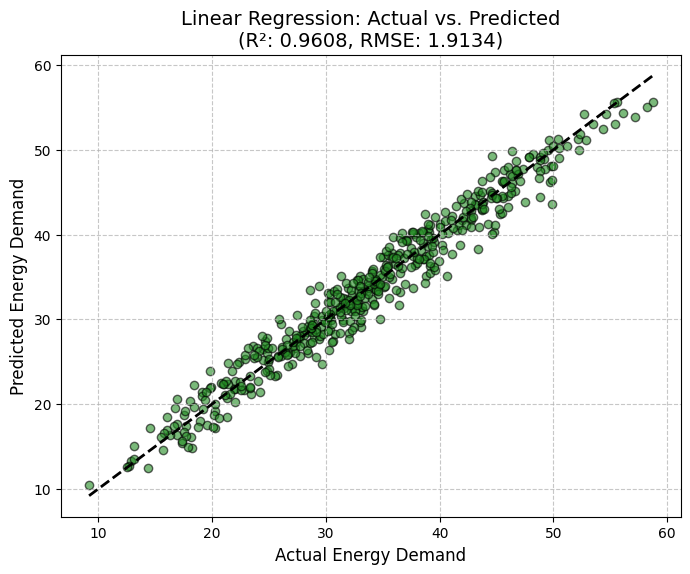

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Identify numeric columns to use as features (excluding the target itself)
target_col = 'predicted_energy_demand'

# Dynamically select all available numeric features from the green building dataset
numeric_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

print(f"Selected Features for Prediction: {numeric_cols}")

X = df2[numeric_cols].values
y = df2[target_col].values

# 2. Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = lr_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Evaluation ---")
print(f"Test RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# 5. Plotting Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='forestgreen', alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Energy Demand', fontsize=12)
plt.ylabel('Predicted Energy Demand', fontsize=12)
plt.title(f'Linear Regression: Actual vs. Predicted\n(R²: {r2:.4f}, RMSE: {rmse:.4f})', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#1. Justification of Parameter Selection
Comprehensive Multi-Source Approach:
  Energy demand in green buildings is a cumulative response to structural attributes, environmental conditions (temperature, humidity, solar radiation), and dynamic operational factors (occupancy, equipment load).

Automated Feature Selection:
  Using select_dtypes(include=[np.number]) programmatically extracts all relevant numeric variables from the 2,400-sample dataset, ensuring the model utilizes the full multi-source depth without manual selection bias.

Baseline Modeling:
  Fitting an Ordinary Least Squares (OLS) linear model establishes a critical baseline to evaluate if energy demand scales proportionally and predictably with these environmental and physical metrics.

#2. Discussion of Results
High Predictive Power ($R^2 = 0.9608$):
  The linear model achieves an exceptionally high $R^2$ score, meaning that approximately 96.08% of the variance in energy demand can be explained by a linear combination of the selected parameters
  
Low Residual Error ($\text{RMSE} = 1.9134$):
  The low Test RMSE indicates that the model's predictions deviate very little from the actual energy demand values.
  
Visual Confirmation:
  The forest green scatter plot shows that the data points tightly hug the diagonal dashed reference line ($y = x$), confirming that a linear relationship is highly effective for tracking energy consumption in this dataset.

  
  




